The data is a 1D signal, a time series. At a time point, a drug was injected. THe goal is to measure how signal's power in a band  changes in time, before and after the injection. Split the signal into windwos such that the injection moment is at the junction between two windows. This way, no window would contain teh injection moment, and won't blend "before" with "after"

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../fourier/')
path.append('../../signals/')

import stft
import signals as sg

In [3]:
from scipy.signal import periodogram

In [4]:

t_before = 255 # s
t_inject = t_before
t_after = 839 # s
freq = 0.02
fs = 2

A_before = 1
A_after = 1.4

_, x_before = sg.cosine(t_before, freq, fs, amplitude=A_before)
_, x_after = sg.cosine(t_after, freq, fs, amplitude=A_after)

x = np.hstack([x_before, x_after])
t = np.arange(x.size)*(1/fs)

In [5]:

window_size = int((t_inject/1.95)*fs) # half injection time
p = stft.windowed_periodogram(x, fs, window_size=window_size)

(0.0, 0.1)

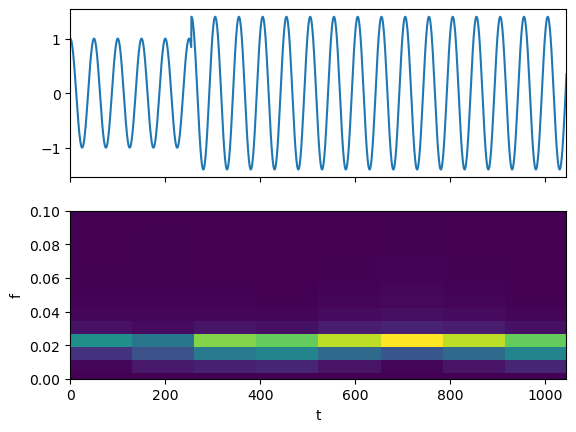

In [6]:
f, (ax,ax1) = plt.subplots(2,1,sharex=True)
ax.plot(t,x)
p.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set_ylim(0,0.1)

## If preinjection time is not integer number of times of the window

In [21]:
t_zeroed = t - t_inject

In [73]:
window_size_s =t_inject/2.23
window_size_s

114.34977578475336

In [74]:
x_trim, t_trim, idx_inj = stft.trim_to_windows_around_injection(x, t_zeroed, 0, window_size_s)

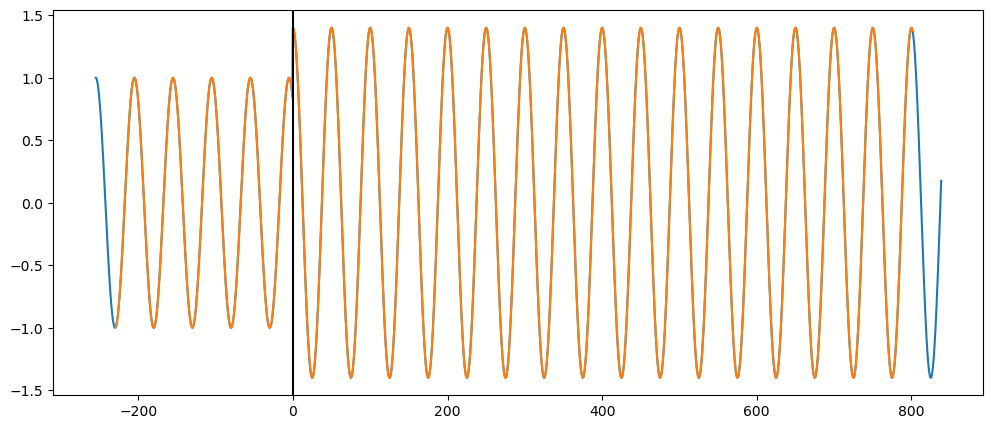

In [75]:
plt.figure(figsize=(12,5))
plt.plot(t_zeroed,x)
plt.plot(t_trim,x_trim)
plt.axvline(t_trim[idx_inj], color='k')

In [93]:
window_size = int(window_size_s*fs)
p = stft.windowed_periodogram(x_trim, fs, window_size=window_size, time_values=t_trim)
p_integrated = p.integrate('f')

[(-309.675, 893.175)]

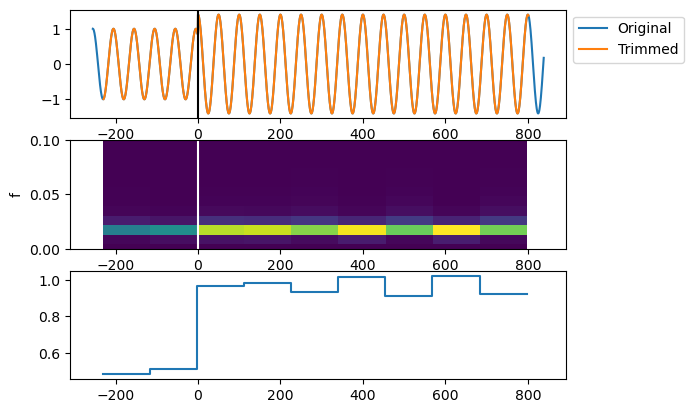

In [94]:
f, (ax,ax1, ax2) = plt.subplots(3,1)

ax.plot(t_zeroed,x, label='Original')
ax.plot(t_trim,x_trim, label='Trimmed')
ax.axvline(t_trim[idx_inj], color='k')
ax.legend(bbox_to_anchor=(1,1))
p.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set(ylim=(0,0.1), xlim=ax.get_xlim())
ax1.axvline(t_trim[idx_inj], color='w')


dt = p_integrated.t.diff('t')[1].item()
edges = np.concatenate([
    [p_integrated.t[0] - dt/2],
    p_integrated.t + dt/2
])
ax2.step(edges, np.r_[p_integrated, p_integrated[-1]], where='post')
ax2.set(xlim=ax.get_xlim())

## Compare with CWT

In [79]:
path.append('../../wavelet/')
import wavelet_funcs as wf

In [98]:
1/t.max()

0.0009144947416552355

(0.01, 0.1)

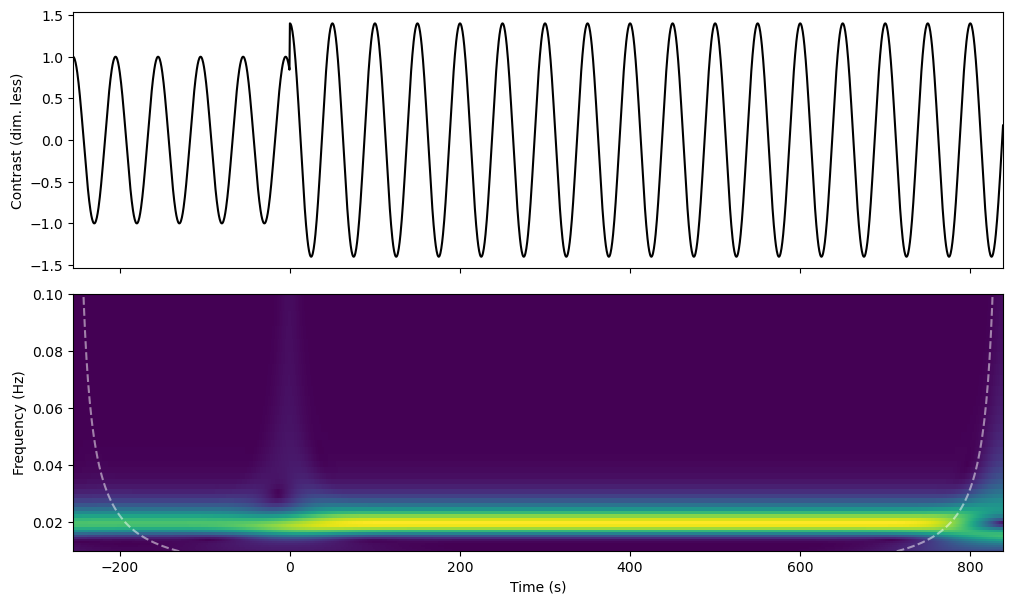

In [100]:
f, (ax,ax1) = wf.plot_timeseries_and_its_cwt(x, t_zeroed, f1=0.001, f2=1, show_smoothed=False)
ax1.set_ylim(0.01, 0.1)

In [103]:
wt = wf.cwt_with_coi(x, t_zeroed, freq_min=0.001, freq_max=1)

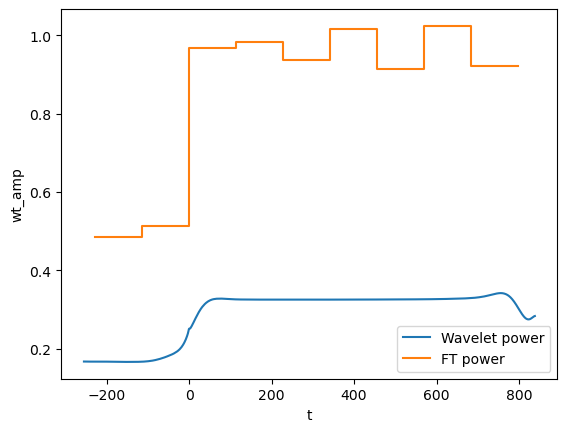

In [104]:
((wt.wt_amp**2).integrate('f')*(-1)).plot(label='Wavelet power')
plt.step(edges, np.r_[p_integrated, p_integrated[-1]], where='post', label='FT power')
plt.legend()

## With noise

In [132]:

t_before = 255 # s
t_inject = t_before
t_after = 839 # s
freq = 0.02
fs = 2

A_before = 1
A_after = 1.4

_, x_before = sg.cosine(t_before, freq, fs, amplitude=A_before)
_, x_after = sg.cosine(t_after, freq, fs, amplitude=A_after)

x = np.hstack([x_before, x_after]) + np.random.randn(x.size)*2
t = np.arange(x.size)*(1/fs)

In [133]:

window_size = int((t_inject/1.95)*fs) # half injection time
p = stft.windowed_periodogram(x, fs, window_size=window_size)

(0.0, 0.1)

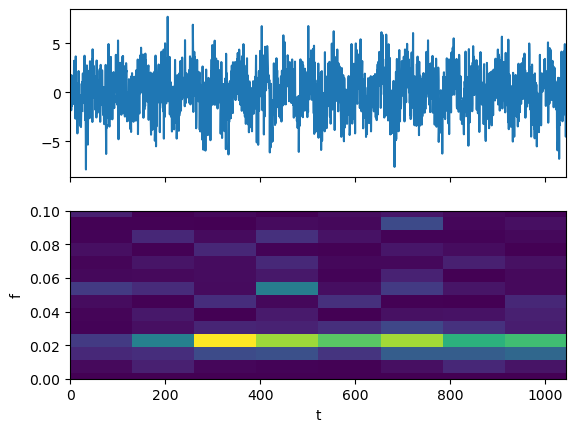

In [134]:
f, (ax,ax1) = plt.subplots(2,1,sharex=True)
ax.plot(t,x)
p.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set_ylim(0,0.1)

## If preinjection time is not integer number of times of the window

In [135]:
t_zeroed = t - t_inject

In [136]:
window_size_s =t_inject/2.23
window_size_s

114.34977578475336

In [137]:
x_trim, t_trim, idx_inj = stft.trim_to_windows_around_injection(x, t_zeroed, 0, window_size_s)

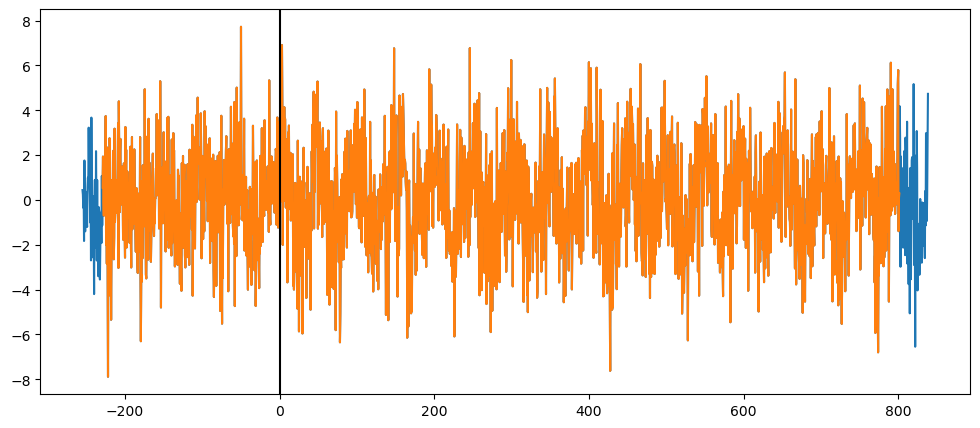

In [138]:
plt.figure(figsize=(12,5))
plt.plot(t_zeroed,x)
plt.plot(t_trim,x_trim)
plt.axvline(t_trim[idx_inj], color='k')

In [139]:
window_size = int(window_size_s*fs)
p = stft.windowed_periodogram(x_trim, fs, window_size=window_size, time_values=t_trim)
p_integrated = p.integrate('f')

[(-309.675, 893.175)]

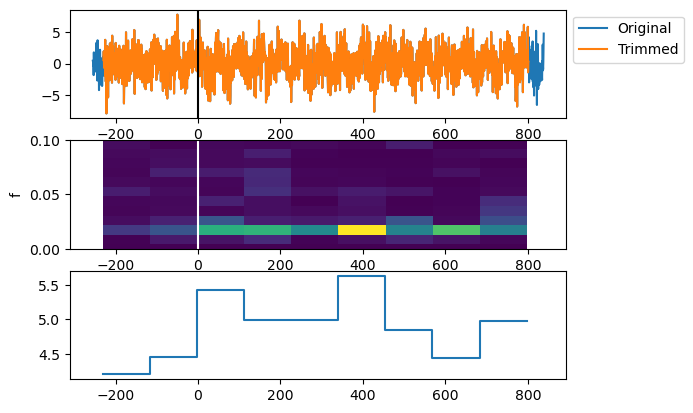

In [140]:
f, (ax,ax1, ax2) = plt.subplots(3,1)

ax.plot(t_zeroed,x, label='Original')
ax.plot(t_trim,x_trim, label='Trimmed')
ax.axvline(t_trim[idx_inj], color='k')
ax.legend(bbox_to_anchor=(1,1))
p.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set(ylim=(0,0.1), xlim=ax.get_xlim())
ax1.axvline(t_trim[idx_inj], color='w')


dt = p_integrated.t.diff('t')[1].item()
edges = np.concatenate([
    [p_integrated.t[0] - dt/2],
    p_integrated.t + dt/2
])
ax2.step(edges, np.r_[p_integrated, p_integrated[-1]], where='post')
ax2.set(xlim=ax.get_xlim())

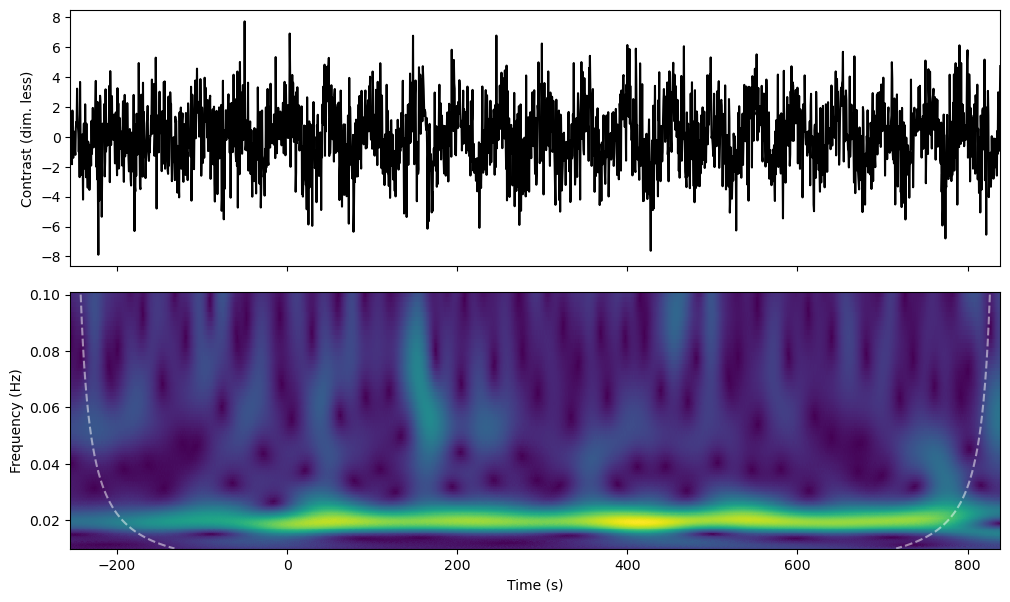

In [141]:
f, (ax,ax1) = wf.plot_timeseries_and_its_cwt(x, t_zeroed, f1=0.01, f2=0.1, show_smoothed=False)

In [142]:
wt = wf.cwt_with_coi(x, t_zeroed, freq_min=0.01, freq_max=0.03)

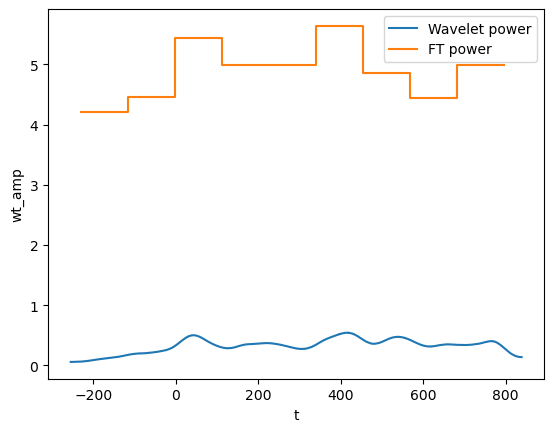

In [143]:
((wt.wt_amp**2).integrate('f')*(-1)).plot(label='Wavelet power')
plt.step(edges, np.r_[p_integrated, p_integrated[-1]], where='post', label='FT power')
plt.legend()